In [1]:
import pandas as pd

In [2]:

sellin = pd.read_csv("https://storage.googleapis.com/open-courses/austral2025-af91/labo3v/sell-in.txt.gz", sep="\t")
productos = pd.read_csv("https://storage.googleapis.com/open-courses/austral2025-af91/labo3v/tb_productos.txt", sep="\t")
stocks = pd.read_csv("https://storage.googleapis.com/open-courses/austral2025-af91/labo3v/tb_stocks.txt", sep="\t")
df = pd.merge(sellin, productos, how="left", on="product_id")
df = df.merge(stocks, how="left", on=["product_id", "periodo"])

In [ ]:
len(df.customer_id.unique())

597

In [ ]:
df.head()

,periodo,customer_id,product_id,plan_precios_cuidados,cust_request_qty,cust_request_tn,tn,cat1,cat2,cat3,brand,sku_size,stock_final
0,201701,10234,20524,0,2,0.05300,0.05300,HC,VAJILLA,Cristalino,Importado,500.0,NaN
1,201701,10032,20524,0,1,0.13628,0.13628,HC,VAJILLA,Cristalino,Importado,500.0,NaN
2,201701,10217,20524,0,1,0.03028,0.03028,HC,VAJILLA,Cristalino,Importado,500.0,NaN
3,201701,10125,20524,0,1,0.02271,0.02271,HC,VAJILLA,Cristalino,Importado,500.0,NaN
4,201701,10012,20524,0,11,1.54452,1.54452,HC,VAJILLA,Cristalino,Importado,500.0,NaN


# Top-down Clientes

### Grafico series de todos los clientes

<Axes: title={'center': 'Ventas por cliente'}, xlabel='periodo_dt'>

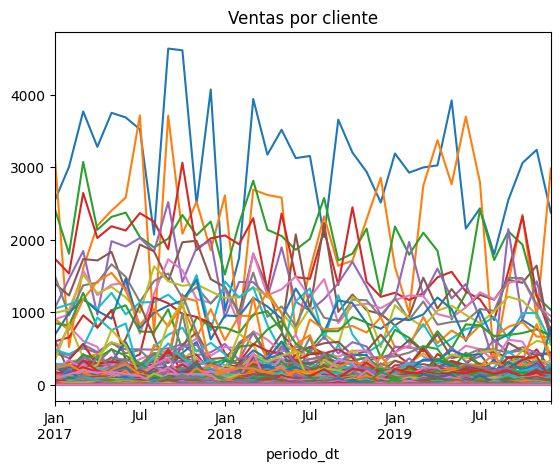

In [3]:
series_cm = pd.pivot_table(df, values="tn", index=["periodo"], columns=["customer_id"], aggfunc="sum",fill_value=0)
series_cm["periodo_dt"] = pd.to_datetime(series_cm.index,format="%Y%m")
series_cm.set_index("periodo_dt",inplace=True)
series_cm.plot(legend=False,title="Ventas por cliente")

<Axes: xlabel='periodo_dt'>

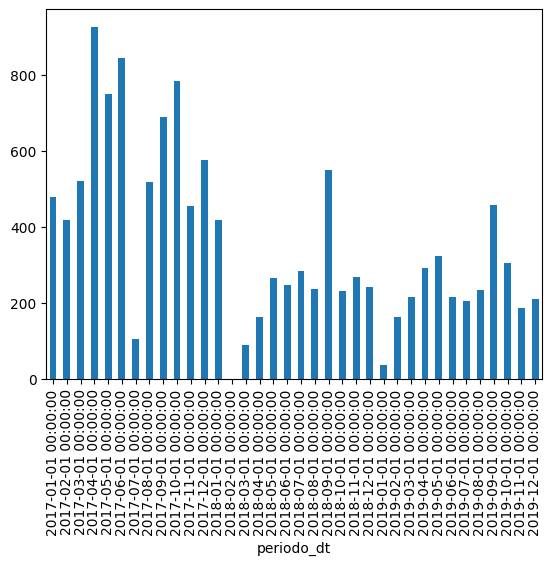

In [6]:
series_cm[10020].plot(kind="bar")

In [7]:
series_cm[10020]

,10020
periodo_dt,
2017-01-01,479.33570
2017-02-01,419.06627
2017-03-01,522.18030
2017-04-01,926.25733
2017-05-01,751.44726
2017-06-01,843.90131
2017-07-01,104.95939
2017-08-01,518.40420
2017-09-01,688.36044


Top 5 clientes

<Axes: title={'center': 'Ventas top 5 clientes'}, xlabel='periodo_dt'>

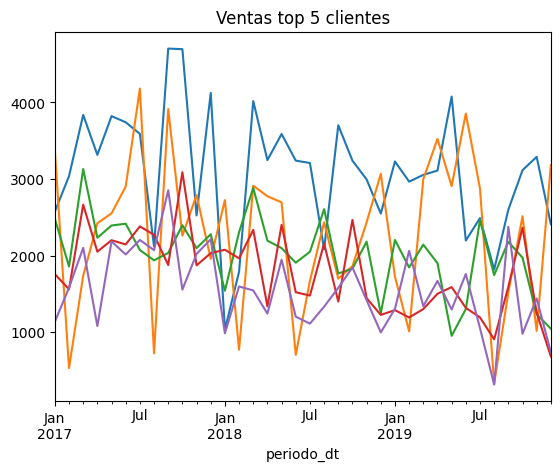

In [ ]:
series_cm[list(series_cm.columns[:5])].plot(legend=False,title="Ventas top 5 clientes")

### dividir Clientes en 10 grupos por cantidades

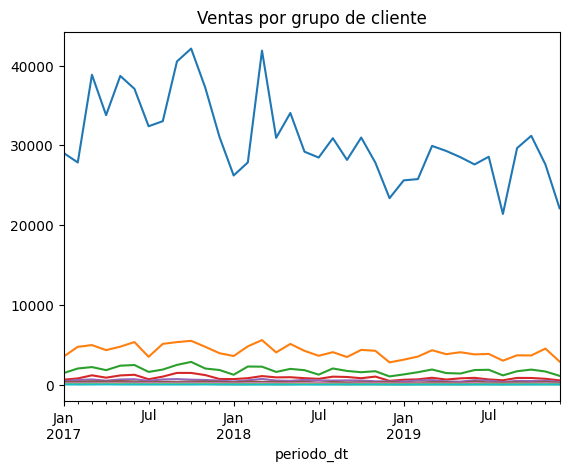

In [ ]:
def dividir_lista(lista, partes=10):
    longitud = len(lista)
    return [lista[i*longitud//partes:(i+1)*longitud//partes]
            for i in range(partes)]

listas_clientes = dividir_lista(list(series_cm.columns))

for clientes in listas_clientes:
    series_cm[clientes].sum(axis=1).plot(legend=False,x="periodo_dt",title="Ventas por grupo de cliente")


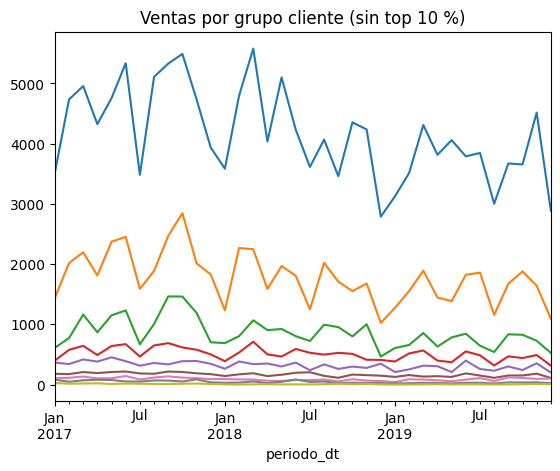

In [ ]:
for clientes in listas_clientes[1:]:
    series_cm[clientes].sum(axis=1).plot(legend=False,x="periodo_dt",title="Ventas por grupo cliente (sin top 10 %)")

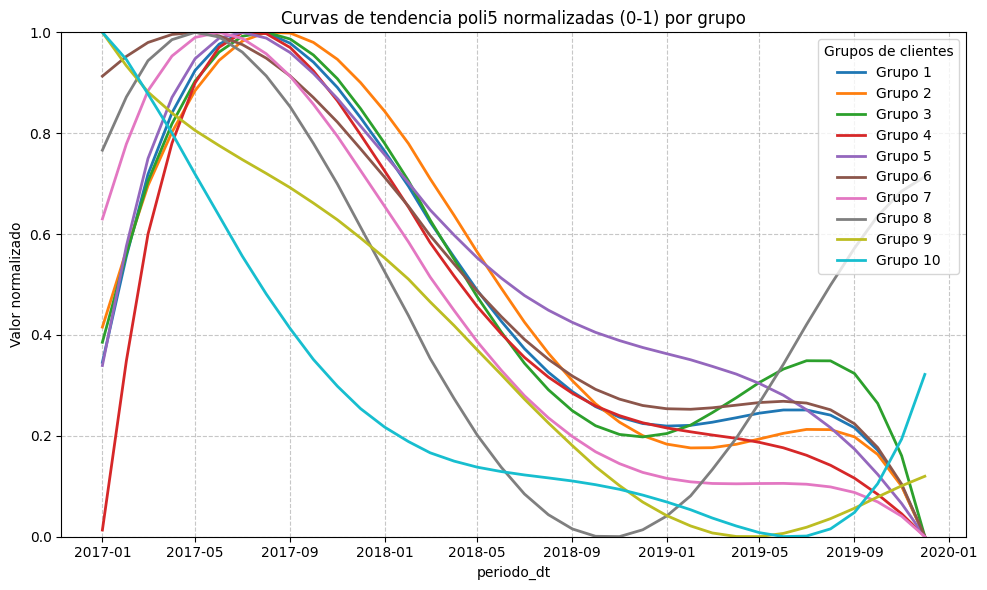

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))  # Tamaño del gráfico

# Iterar sobre las listas de clientes con enumeración
for i, clientes in enumerate(listas_clientes, start=1):
    # Obtener los datos de la serie
    datos = series_cm[clientes].sum(axis=1)

    # Preparar datos para el ajuste polinómico
    x = np.arange(len(datos))  # Crear array de índices
    y = datos.values  # Valores de la serie

    # Ajustar polinomio de grado 2 (poli5)
    coeficientes = np.polyfit(x, y, 5)
    polinomio = np.poly1d(coeficientes)
    tendencia = polinomio(x)

    # Normalizar la tendencia entre 0 y 1
    tendencia_normalizada = (tendencia - tendencia.min()) / (tendencia.max() - tendencia.min())

    # Graficar SOLO la curva de tendencia normalizada con etiqueta "Grupo X"
    plt.plot(datos.index, tendencia_normalizada,
             label=f'Grupo {i}',
             linestyle='-',
             linewidth=2)

# Configuración del gráfico
plt.title("Curvas de tendencia poli5 normalizadas (0-1) por grupo")
plt.xlabel("periodo_dt")
plt.ylabel("Valor normalizado")
plt.ylim(0, 1)  # Asegurar rango 0-1
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Grupos de clientes")  # Añadir título a la leyenda
plt.tight_layout()
plt.show()

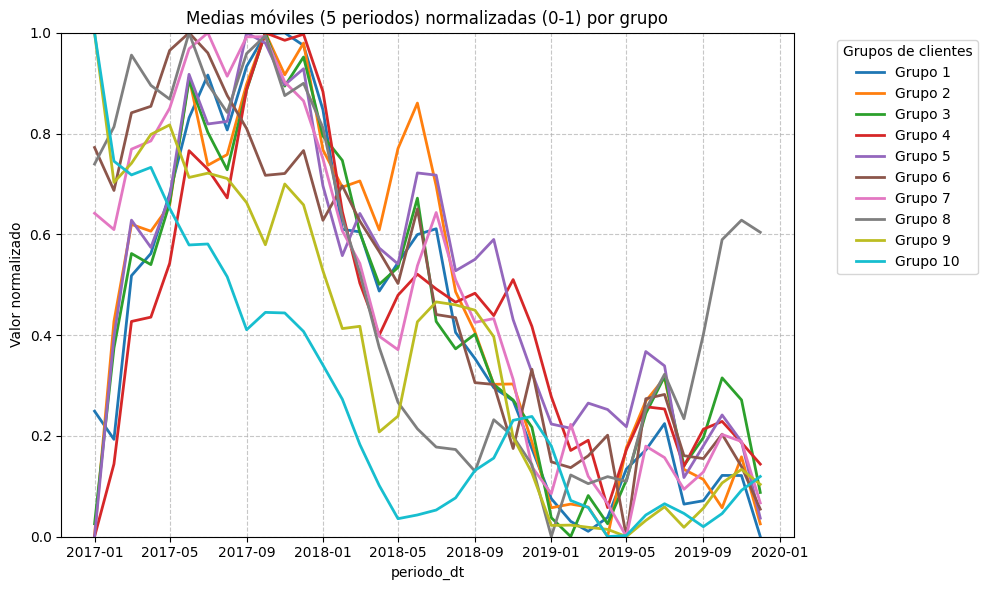

In [ ]:

plt.figure(figsize=(10, 6))  # Tamaño del gráfico

# Iterar sobre las listas de clientes con enumeración
for i, clientes in enumerate(listas_clientes, start=1):
    # Obtener los datos de la serie
    datos = series_cm[clientes].sum(axis=1)

    # Calcular media móvil de 5 periodos
    media_movil = datos.rolling(window=5, min_periods=1).mean()

    # Normalizar entre 0 y 1
    media_movil_normalizada = (media_movil - media_movil.min()) / (media_movil.max() - media_movil.min())

    # Graficar la media móvil normalizada
    plt.plot(datos.index, media_movil_normalizada,
             label=f'Grupo {i}',
             linestyle='-',
             linewidth=2)

# Configuración del gráfico
plt.title("Medias móviles (5 periodos) normalizadas (0-1) por grupo")
plt.xlabel("periodo_dt")
plt.ylabel("Valor normalizado")
plt.ylim(0, 1)  # Asegurar rango 0-1
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Grupos de clientes", bbox_to_anchor=(1.05, 1), loc='upper left')  # Leyenda fuera del gráfico
plt.tight_layout()
plt.show()

Cuanto de cada categoria de producto compran los clientes??

In [ ]:
pxc = pd.pivot_table(df, values="tn", index=["customer_id"], columns="cat1", aggfunc="sum", fill_value=0)
pxc = pxc.reset_index()

pxc["grupo_cliente"] = ""  # Inicializar columna

# Asignar grupo basado en listas_clientes
for i, lista in enumerate(listas_clientes, start=1):
    for ci in lista:
        pxc.loc[pxc["customer_id"] == ci, "grupo_cliente"] = i

# Verificar si hay clientes sin grupo asignado
if (pxc["grupo_cliente"] == "").any():
    print("⚠️ Algunos clientes no tienen grupo asignado:")
    print(pxc[pxc["grupo_cliente"] == ""])
else:
    print("✅ Todos los clientes fueron asignados a un grupo correctamente.")

pxc.head()

✅ Todos los clientes fueron asignados a un grupo correctamente.


cat1,customer_id,FOODS,HC,PC,REF,grupo_cliente
0,10001,21011.48517,72563.27290,17479.52644,25.34767,1
1,10002,14431.17396,52896.59679,15224.43621,0.52091,1
2,10003,14873.47214,47697.90868,10337.39052,17.52205,1
3,10004,11398.58793,41401.50699,11081.24049,5.43551,1
4,10005,9936.50153,37059.74974,9148.55958,0.61316,1


<Axes: xlabel='grupo_cliente'>

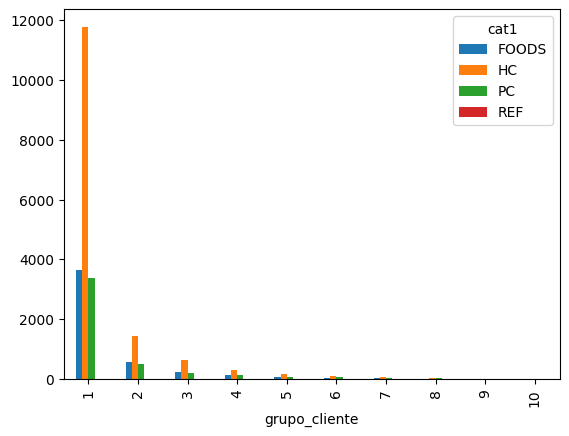

In [ ]:
pxgc = pxc.groupby("grupo_cliente").agg("mean")[["FOODS","HC","PC","REF"]]
pxgc.plot(kind="bar")

In [ ]:
pxgc

cat1,FOODS,HC,PC,REF
grupo_cliente,,,,
1,3655.276837,11772.237031,3366.571138,1.458758
2,560.793395,1446.877377,487.733145,0.081602
3,244.193867,628.044194,194.019823,0.045149
4,121.110807,286.437224,116.926333,0.019463
5,64.559876,169.016936,72.350486,0.014985
6,38.350960,101.038458,53.210651,0.006772
7,21.594293,53.897342,27.074438,0.005628
8,8.219174,28.659654,18.412291,0.002636
9,6.914459,12.153301,8.077048,0.005226


In [ ]:
pd.DataFrame({"PC/HC":pxgc["PC"]/pxgc["HC"],"FOODS/HC":pxgc['FOODS']/pxgc["HC"]})

,PC/HC,FOODS/HC
grupo_cliente,,
1,0.285975,0.310500
2,0.337094,0.387589
3,0.308927,0.388816
4,0.408209,0.422818
5,0.428066,0.381973
6,0.526638,0.379568
7,0.502333,0.400656
8,0.642446,0.286786
9,0.664597,0.568937


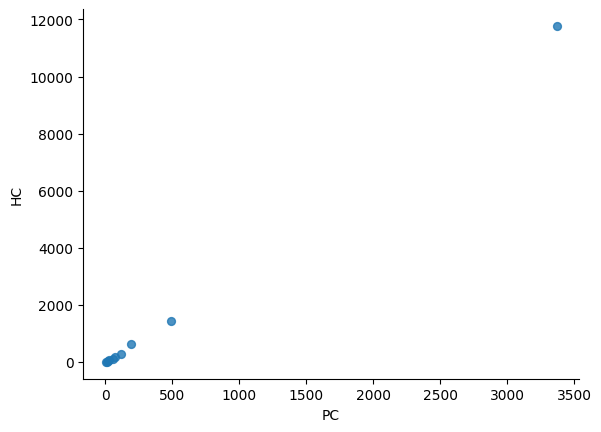

In [ ]:
pxgc.plot(kind='scatter', x='PC', y='HC', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

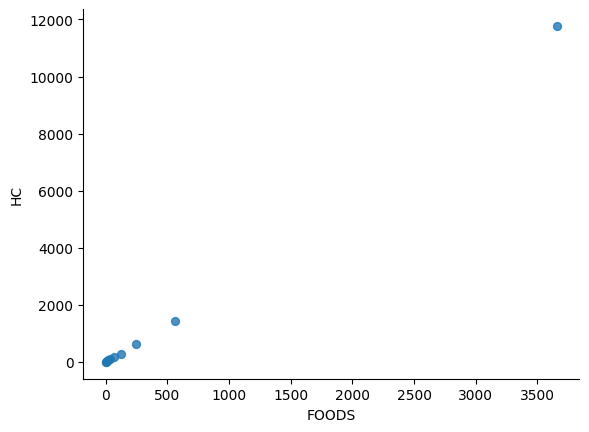

In [ ]:
pxgc.plot(kind='scatter', x='FOODS', y='HC', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

Cuantos productos compra cada cliente?

In [ ]:
pxcQ = pd.pivot_table(df, values="product_id", index=["customer_id"], columns="cat1", aggfunc="count", fill_value=0)
pxcQ = pxcQ.reset_index()

pxcQ["grupo_cliente"] = ""  # Inicializar columna

# Asignar grupo basado en listas_clientes
for i, lista in enumerate(listas_clientes, start=1):
    for ci in lista:
        pxcQ.loc[pxcQ["customer_id"] == ci, "grupo_cliente"] = i

# Verificar si hay clientes sin grupo asignado
if (pxcQ["grupo_cliente"] == "").any():
    print("⚠️ Algunos clientes no tienen grupo asignado:")
    print(pxcQ[pxcQ["grupo_cliente"] == ""])
else:
    print("✅ Todos los clientes fueron asignados a un grupo correctamente.")

pxcQ.head()

✅ Todos los clientes fueron asignados a un grupo correctamente.


cat1,customer_id,FOODS,HC,PC,REF,grupo_cliente
0,10001,5028,6370,13343,294,1
1,10002,4610,6172,12657,44,1
2,10003,3966,6168,13612,233,1
3,10004,4867,6387,12935,215,1
4,10005,4613,5860,10932,55,1


<Axes: xlabel='grupo_cliente'>

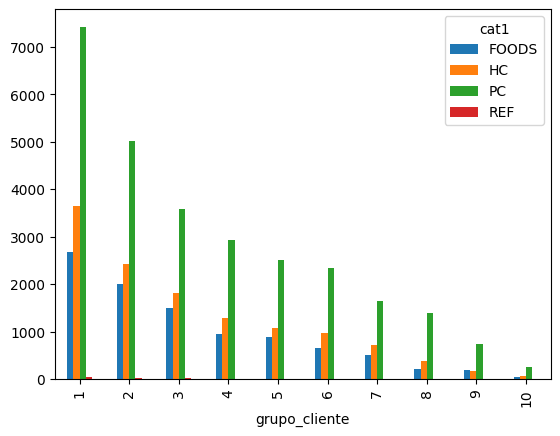

In [ ]:
pxgcQ = pxcQ.groupby("grupo_cliente").agg("mean")[["FOODS","HC","PC","REF"]]
pxgcQ.plot(kind="bar")

In [ ]:
pxgcQ

cat1,FOODS,HC,PC,REF
grupo_cliente,,,,
1,2666.457627,3653.338983,7421.813559,48.525424
2,1994.500000,2428.266667,5013.383333,19.033333
3,1505.200000,1809.716667,3589.050000,11.866667
4,951.322034,1278.932203,2919.847458,6.508475
5,888.050000,1066.216667,2505.716667,6.916667
6,647.683333,969.600000,2341.000000,3.833333
7,500.440678,722.118644,1649.237288,3.203390
8,200.466667,383.100000,1392.650000,1.416667
9,190.266667,173.750000,727.050000,2.250000


In [ ]:
pd.DataFrame({"HC/PC":pxgcQ["HC"]/pxgcQ["PC"],"FOODS/PC":pxgcQ['FOODS']/pxgcQ["PC"]})


,HC/PC,FOODS/PC
grupo_cliente,,
1,0.492243,0.359273
2,0.484357,0.397835
3,0.504233,0.419387
4,0.438013,0.325812
5,0.425514,0.354410
6,0.414182,0.276670
7,0.437850,0.303438
8,0.275087,0.143946
9,0.238979,0.261697


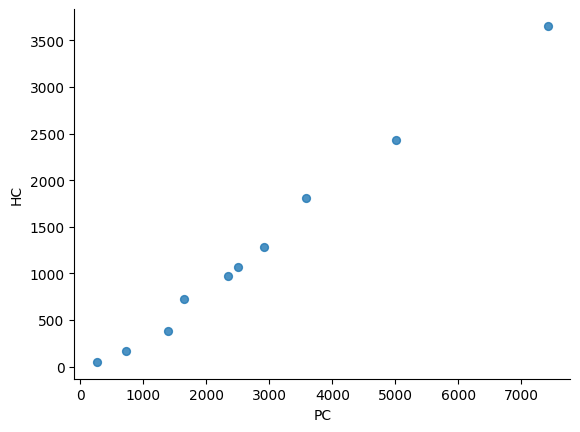

In [ ]:
pxgcQ.plot(kind='scatter', x='PC', y='HC', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

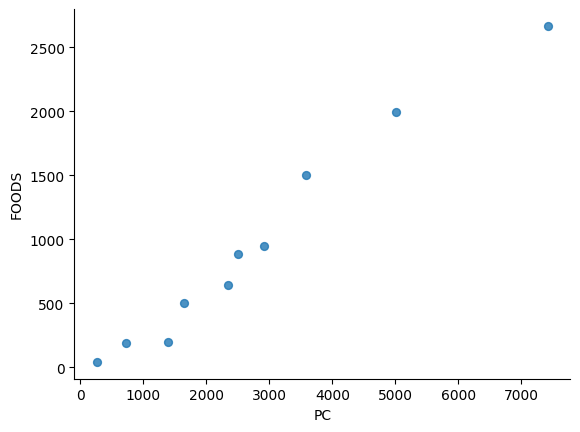

In [ ]:
pxgcQ.plot(kind='scatter', x='PC', y='FOODS', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

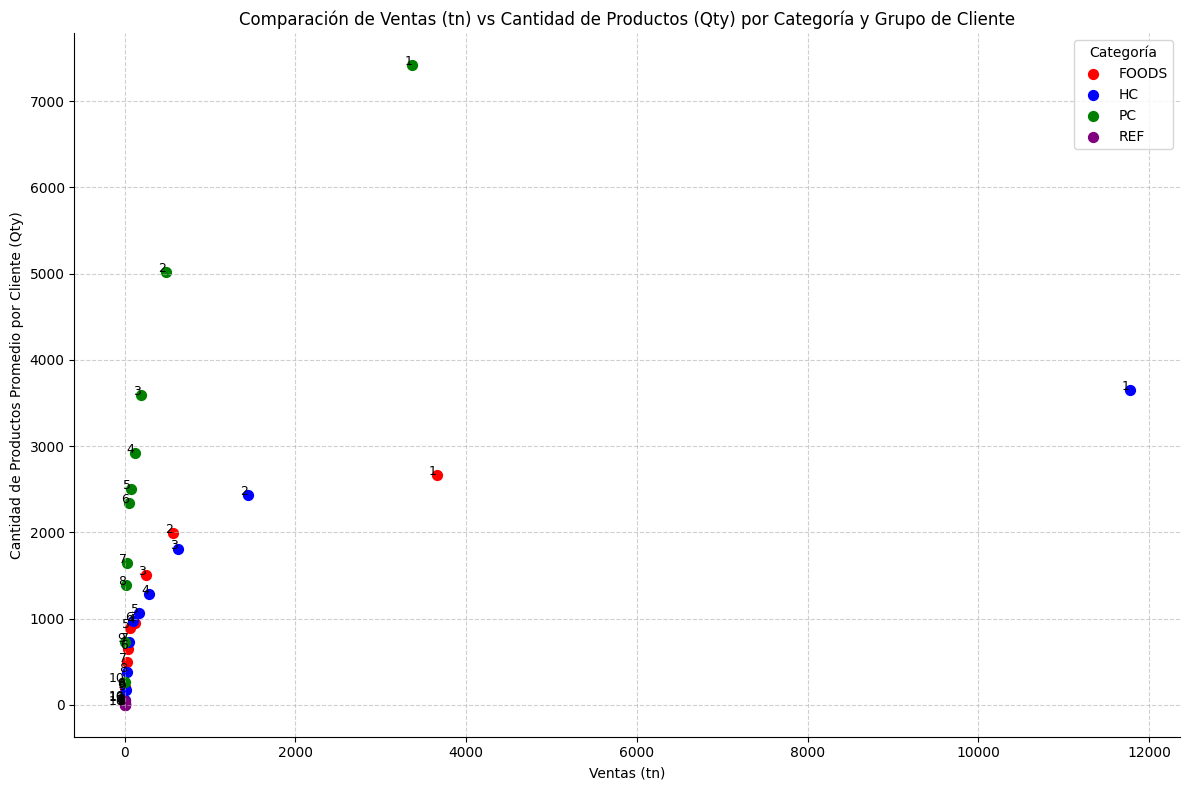

In [ ]:
# prompt: graficar pxgcQ y pxgc en cada eje, cada columna debe ser de un color

import pandas as pd
import matplotlib.pyplot as plt
# Preparar los datos para el gráfico
# Combinar pxgc y pxgcQ en un solo DataFrame para facilitar el ploteo
# Asegúrate de que ambos DataFrames tienen el mismo índice (grupo_cliente)
pxgc_plot = pxgc.reset_index()
pxgcQ_plot = pxgcQ.reset_index()

# Asigna nombres a las columnas para distinguirlas después de la unión
pxgc_plot.columns = [f'{col}_tn' if col != 'grupo_cliente' else col for col in pxgc_plot.columns]
pxgcQ_plot.columns = [f'{col}_qty' if col != 'grupo_cliente' else col for col in pxgcQ_plot.columns]

merged_data = pd.merge(pxgc_plot, pxgcQ_plot, on='grupo_cliente')

# Crear el gráfico de dispersión
plt.figure(figsize=(12, 8))

# Definir colores para cada columna
colors = ['red', 'blue', 'green', 'purple'] # Colores para FOODS, HC, PC, REF

# Graficar cada par de columnas (pxgc y pxgcQ) con un color diferente
plt.scatter(merged_data['FOODS_tn'], merged_data['FOODS_qty'], label='FOODS', color=colors[0], s=50)
plt.scatter(merged_data['HC_tn'], merged_data['HC_qty'], label='HC', color=colors[1], s=50)
plt.scatter(merged_data['PC_tn'], merged_data['PC_qty'], label='PC', color=colors[2], s=50)
plt.scatter(merged_data['REF_tn'], merged_data['REF_qty'], label='REF', color=colors[3], s=50)


# Añadir etiquetas para cada punto (grupo de cliente)
for i, row in merged_data.iterrows():
    plt.text(row['FOODS_tn'], row['FOODS_qty'], str(int(row['grupo_cliente'])), fontsize=9, ha='right')
    plt.text(row['HC_tn'], row['HC_qty'], str(int(row['grupo_cliente'])), fontsize=9, ha='right')
    plt.text(row['PC_tn'], row['PC_qty'], str(int(row['grupo_cliente'])), fontsize=9, ha='right')
    plt.text(row['REF_tn'], row['REF_qty'], str(int(row['grupo_cliente'])), fontsize=9, ha='right')


# Configuración del gráfico
plt.title('Comparación de Ventas (tn) vs Cantidad de Productos (Qty) por Categoría y Grupo de Cliente')
plt.xlabel('Ventas (tn)')
plt.ylabel('Cantidad de Productos Promedio por Cliente (Qty)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Categoría')

# Eliminar bordes superiores y derechos
plt.gca().spines[['top', 'right',]].set_visible(False)

plt.tight_layout()
plt.show()